# Demo of the Synthetic Data Generation
The synthetical data generation is done executing the `../utils/SCI3000SyntheticCompoundStitcher.py`.
1160 figures from the dataset were labeled as single figures and then used to create the compound figures. In total, 10.000 compound figures were generated and the following cell serves as a demo on what the compound figures and their labels look like.

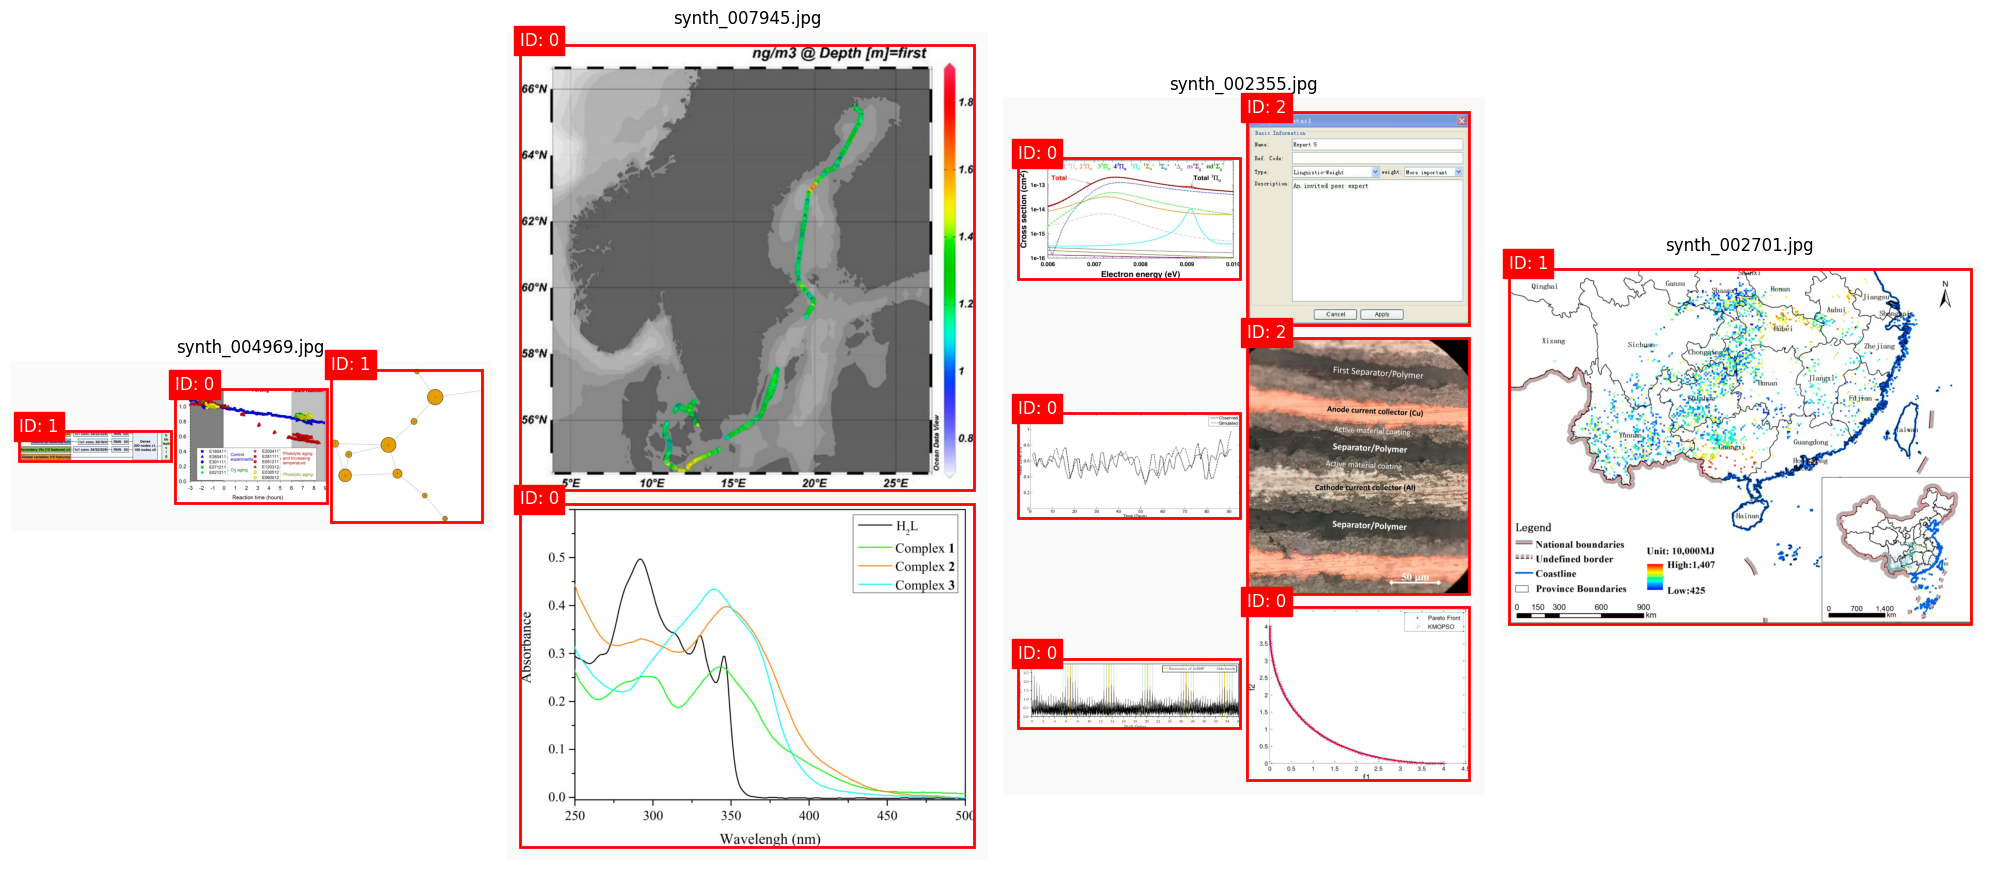

In [1]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

SYNTHETIC_DIR = "../../dataset/03_intermediate/SCI-3000_synthetic-generated"
IMG_DIR = os.path.join(SYNTHETIC_DIR, "images")
LABEL_DIR = os.path.join(SYNTHETIC_DIR, "yolo-labels")

def display_samples(num_samples=4):
    """Lädt zufällige generierte Bilder und visualisiert die YOLO-Labels."""
    
    if not os.path.exists(IMG_DIR):
        print(f"Ordner nicht gefunden: {IMG_DIR}. Bitte erst Generator ausführen!")
        return

    all_files = [f for f in os.listdir(IMG_DIR) if f.endswith(('.png', '.jpg'))]
    
    if not all_files:
        print("Keine Bilder gefunden.")
        return

    selected_files = random.sample(all_files, min(num_samples, len(all_files)))

    fig, axes = plt.subplots(1, len(selected_files), figsize=(20, 10))
    if len(selected_files) == 1: axes = [axes]

    for ax, filename in zip(axes, selected_files):
        img_path = os.path.join(IMG_DIR, filename)
        label_path = os.path.join(LABEL_DIR, filename.replace(".png", ".txt").replace(".jpg", ".txt"))
        
        try:
            im = Image.open(img_path)
            w, h = im.size
            ax.imshow(im)
            
            if os.path.exists(label_path):
                with open(label_path, 'r') as f:
                    lines = f.readlines()
                    
                for line in lines:
                    parts = line.strip().split()
                    class_id = int(parts[0])
                    x_center, y_center, box_w, box_h = map(float, parts[1:])
                    
                    x1 = (x_center - box_w / 2) * w
                    y1 = (y_center - box_h / 2) * h
                    bw = box_w * w
                    bh = box_h * h
                    
                    rect = patches.Rectangle((x1, y1), bw, bh, linewidth=2, edgecolor='r', facecolor='none')
                    ax.add_patch(rect)
                    
                    ax.text(x1, y1, f"ID: {class_id}", color='white', fontsize=12, backgroundcolor="red")
            
            ax.set_title(filename)
            ax.axis('off')
            
        except Exception as e:
            print(f"Fehler bei {filename}: {e}")

    plt.tight_layout()
    plt.show()

display_samples(4)

Visualize some synthetically generated plots, aiming to improve shared axis, shared title and shared legend detection performance.

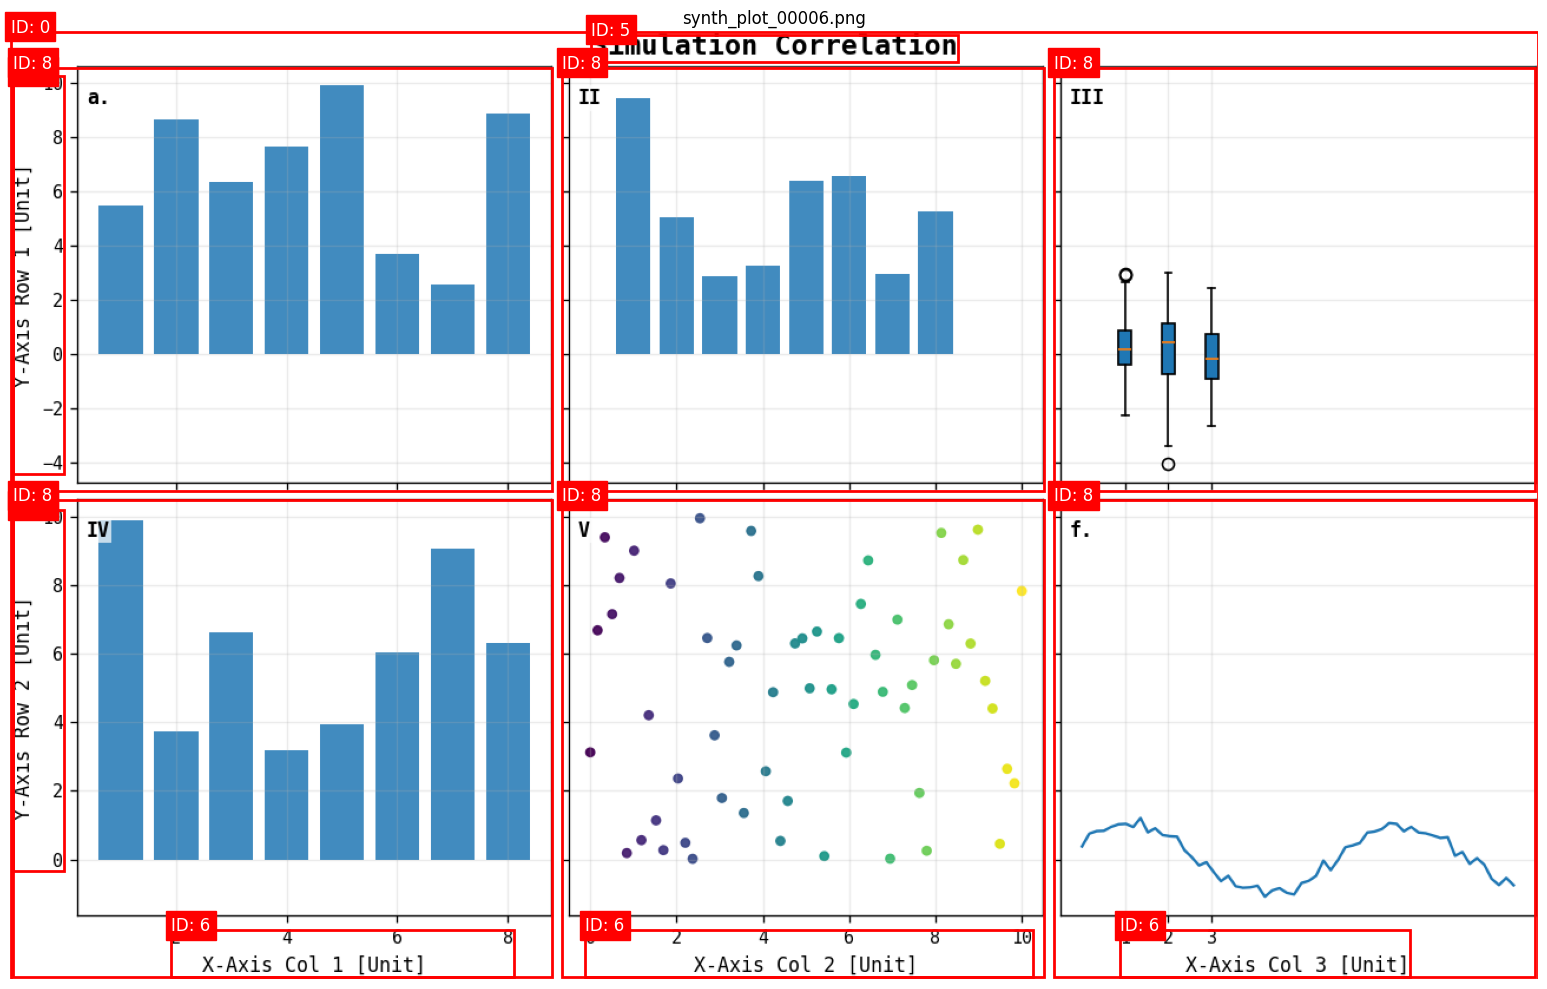

In [3]:
SYNTHETIC_DIR = "../../dataset/03_intermediate/SyntheticCompoundPlots"
IMG_DIR = os.path.join(SYNTHETIC_DIR, "images")
LABEL_DIR = os.path.join(SYNTHETIC_DIR, "yolo-labels")

display_samples(1)